In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the CSV file
df = pd.read_csv('data/train.csv')

# See the size: rows x columns
print("Shape:", df.shape)

# See first 5 rows
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# See statistics of the price column
print(df['SalePrice'].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


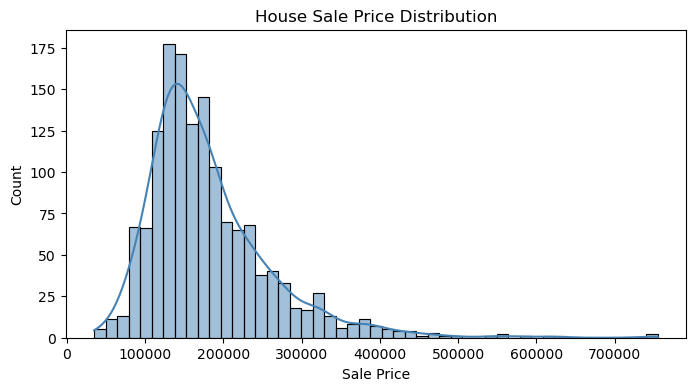

In [4]:
# Draw a histogram to see how prices are spread
plt.figure(figsize=(8, 4))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title('House Sale Price Distribution')
plt.xlabel('Sale Price')
plt.show()

In [5]:
# Correlation = how much each feature is related to price
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

print("Top 10 features that affect price most:")
print(corr[:11])

Top 10 features that affect price most:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


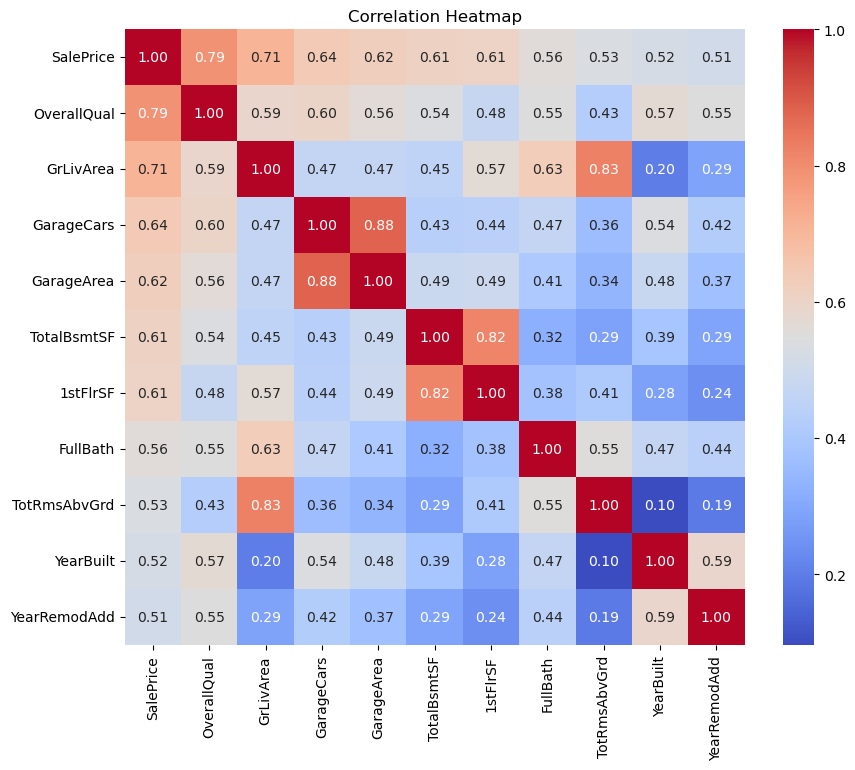

In [6]:
# Draw a heatmap to visualize correlations
top_features = corr[:11].index
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
# Drop columns that have too many missing values
df.drop(columns=['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'], inplace=True)

# Fill missing numbers with the median value
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing text columns with the most common value
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values remaining:", df.isnull().sum().sum())

C:\Users\sathw\AppData\Local\Temp\ipykernel_26884\4247169187.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Missing values remaining: 0


In [8]:
# ML models only understand numbers, not text like "Good" or "Excellent"
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("All columns are now numbers. Shape:", df.shape)

All columns are now numbers. Shape: (1460, 76)


In [9]:
# Log transform the price (makes model more accurate)
df['SalePrice'] = np.log1p(df['SalePrice'])

# Create new smart features from existing ones
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

print("New features created! Shape:", df.shape)

New features created! Shape: (1460, 80)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X = inputs (features), y = output (price)
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

# 80% for training, 20% for testing
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the numbers (puts everything on same scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training rows: {X_train.shape[0]}")
print(f"Validation rows: {X_val.shape[0]}")
print("Data is ready for ML!")

Training rows: 1168
Validation rows: 292
Data is ready for ML!


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on validation data
lr_preds = lr_model.predict(X_val_scaled)

# Check accuracy
rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
r2 = r2_score(y_val, lr_preds)

print(f"Linear Regression Results:")
print(f"R² Score: {r2:.4f}  (closer to 1.0 = better)")
print(f"RMSE: {rmse:.4f}")

Linear Regression Results:
R² Score: 0.8719  (closer to 1.0 = better)
RMSE: 0.1546


In [12]:
import xgboost as xgb

# Create and train XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)

# Predict
xgb_preds = xgb_model.predict(X_val_scaled)

# Check accuracy
rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
r2 = r2_score(y_val, xgb_preds)

print(f"XGBoost Results:")
print(f"R² Score: {r2:.4f}  (closer to 1.0 = better)")
print(f"RMSE: {rmse:.4f}")

ModuleNotFoundError: No module named 'xgboost'

In [13]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)
print("XGBoost installed!")

XGBoost installed!


In [14]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)

xgb_preds = xgb_model.predict(X_val_scaled)

rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
r2 = r2_score(y_val, xgb_preds)

print(f"XGBoost Results:")
print(f"R² Score: {r2:.4f}  (closer to 1.0 = better)")
print(f"RMSE: {rmse:.4f}")

XGBoost Results:
R² Score: 0.8767  (closer to 1.0 = better)
RMSE: 0.1517


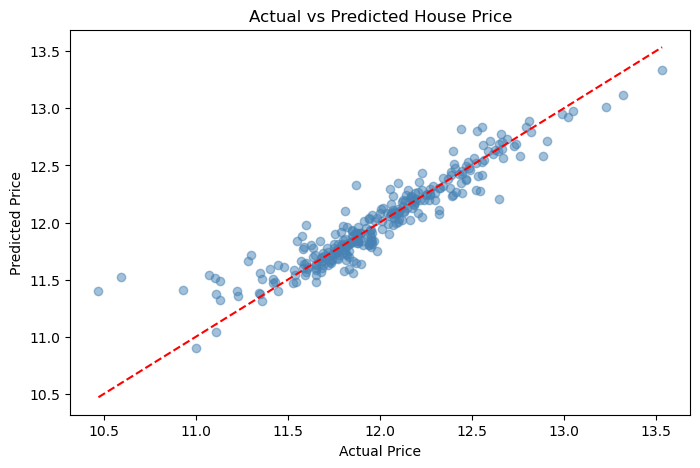

In [15]:
# Actual vs Predicted chart
plt.figure(figsize=(8, 5))
plt.scatter(y_val, xgb_preds, alpha=0.5, color='steelblue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Price')
plt.show()

In [16]:
import joblib

joblib.dump(xgb_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("Model saved successfully!")

Model saved successfully!
